# PCL Exploratory Data Analysis
**Task:** SemEval-2022 Task 4 — Patronizing and Condescending Language (PCL) Detection  
**Subtask 1:** Binary classification — PCL vs No-PCL

This notebook covers 6 EDA techniques:  
1. Class Distribution & Label Granularity  
2. Text Length Analysis  
3. Keyword / Vulnerable-Community Distribution  
4. N-gram Analysis (Lexical Patterns)  
5. PCL Category Distribution & Co-occurrence  
6. Word Cloud Visualisation  

In [1]:
# ── 0. Imports & Setup ──────────────────────────────────────────────────────
import sys, os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.util import ngrams

from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer

# ── Paths ───────────────────────────────────────────────────────────────────
REPO_ROOT  = os.path.abspath('.')
TRAIN_PATH = os.path.join(REPO_ROOT, 'NLPLabs-2024', 'Dont_Patronize_Me_Trainingset')
TEST_PATH  = os.path.join(REPO_ROOT, 'dontpatronizeme', 'semeval-2022', 'TEST', 'task4_test.tsv')
HELPER_DIR = os.path.join(REPO_ROOT, 'dontpatronizeme', 'semeval-2022')
FIG_DIR    = os.path.join(REPO_ROOT, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

sys.path.insert(0, HELPER_DIR)
from dont_patronize_me import DontPatronizeMe

# ── Style ───────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
PCL_COLORS = {0: '#4C72B0', 1: '#DD8452'}   # blue=No-PCL, orange=PCL

print('Setup complete.')

Setup complete.


In [2]:
# ── Load Data ────────────────────────────────────────────────────────────────
dpm = DontPatronizeMe(TRAIN_PATH, TEST_PATH)
dpm.load_task1()   # binary labels
dpm.load_task2()   # category labels

df  = dpm.train_task1_df.copy()   # main dataframe
df2 = dpm.train_task2_df.copy()   # category dataframe

print(f'Task-1 dataset: {len(df):,} paragraphs')
print(f'Task-2 dataset: {len(df2):,} paragraphs with category labels')
df.head(3)

Map of label to numerical label:
{'Unbalanced_power_relations': 0, 'Shallow_solution': 1, 'Presupposition': 2, 'Authority_voice': 3, 'Metaphors': 4, 'Compassion': 5, 'The_poorer_the_merrier': 6}
Task-1 dataset: 10,469 paragraphs
Task-2 dataset: 993 paragraphs with category labels


,par_id,art_id,keyword,country,text,label,orig_label
0,1,@@24942188,hopeless,ph,"We 're living in times of absolute insanity , ...",0,0
1,2,@@21968160,migrant,gh,"In Libya today , there are countless number of...",0,0
2,3,@@16584954,immigrant,ie,"""White House press secretary Sean Spicer said ...",0,0


---
## EDA 1 — Class Distribution & Label Granularity

In [3]:
# ── EDA 1: Class Distribution ────────────────────────────────────────────────
binary_counts = df['label'].value_counts().sort_index()
orig_counts   = df['orig_label'].astype(int).value_counts().sort_index()

# Summary table
binary_pct = (binary_counts / len(df) * 100).round(1)
orig_pct   = (orig_counts   / len(df) * 100).round(1)

print('=== Binary label distribution ===')
summary = pd.DataFrame({
    'Label': ['0 — No PCL', '1 — PCL'],
    'Count': binary_counts.values,
    'Percentage': binary_pct.values
})
print(summary.to_string(index=False))
print(f'\nImbalance ratio (No-PCL : PCL) = {binary_counts[0]/binary_counts[1]:.1f} : 1')

print('\n=== Fine-grained label distribution ===')
label_desc = {
    0: 'Both annotators: No PCL',
    1: 'Mixed: No PCL / Borderline',
    2: 'Both annotators: Borderline PCL',
    3: 'Mixed: Borderline / Strong PCL',
    4: 'Both annotators: Strong PCL'
}
orig_summary = pd.DataFrame({
    'Label': list(orig_counts.index),
    'Description': [label_desc[i] for i in orig_counts.index],
    'Count': orig_counts.values,
    'Percentage (%)': orig_pct.values
})
print(orig_summary.to_string(index=False))

=== Binary label distribution ===
     Label  Count  Percentage
0 — No PCL   9476        90.5
   1 — PCL    993         9.5

Imbalance ratio (No-PCL : PCL) = 9.5 : 1

=== Fine-grained label distribution ===
 Label                     Description  Count  Percentage (%)
     0         Both annotators: No PCL   8529            81.5
     1      Mixed: No PCL / Borderline    947             9.0
     2 Both annotators: Borderline PCL    144             1.4
     3  Mixed: Borderline / Strong PCL    458             4.4
     4     Both annotators: Strong PCL    391             3.7


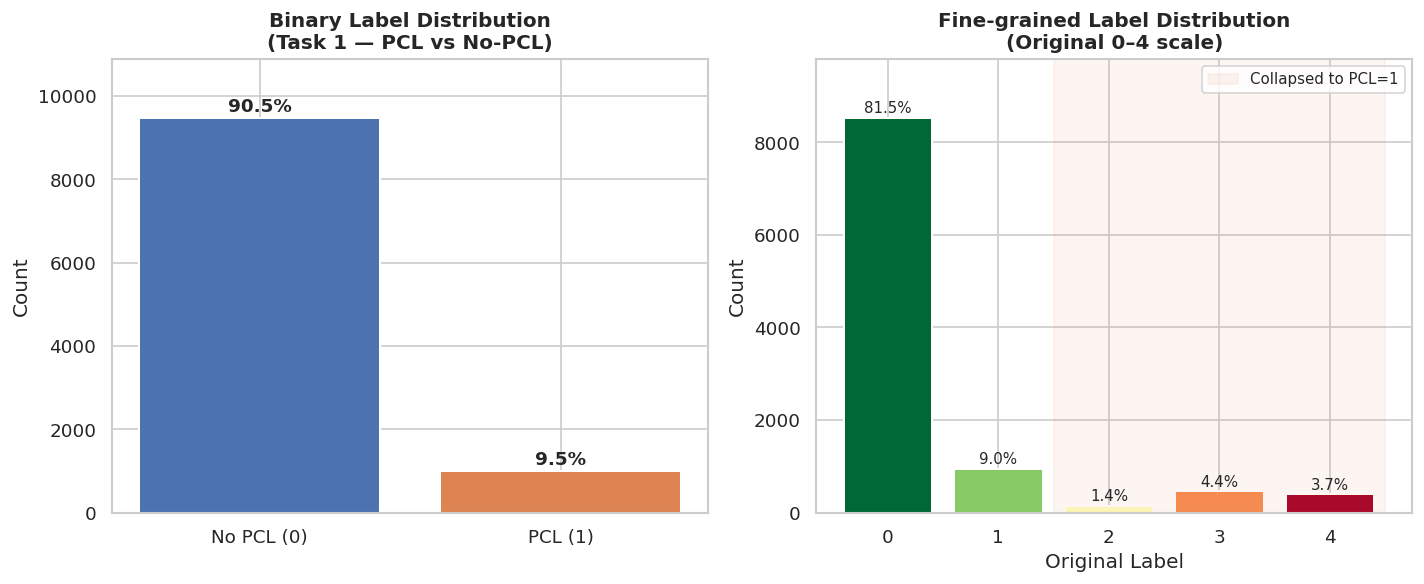

Saved fig1_class_distribution.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: binary
bars = axes[0].bar(
    ['No PCL (0)', 'PCL (1)'],
    binary_counts.values,
    color=[PCL_COLORS[0], PCL_COLORS[1]],
    edgecolor='white', linewidth=1.2
)
for bar, pct in zip(bars, binary_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 60,
                 f'{pct}%', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Binary Label Distribution\n(Task 1 — PCL vs No-PCL)', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, binary_counts.max() * 1.15)

# Right: fine-grained
cmap = plt.cm.RdYlGn_r
fine_colors = [cmap(i/4) for i in range(5)]
bars2 = axes[1].bar(
    [str(i) for i in orig_counts.index],
    orig_counts.values,
    color=fine_colors,
    edgecolor='white', linewidth=1.2
)
for bar, pct in zip(bars2, orig_pct.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 40,
                 f'{pct}%', ha='center', va='bottom', fontsize=9)
axes[1].set_title('Fine-grained Label Distribution\n(Original 0–4 scale)', fontweight='bold')
axes[1].set_xlabel('Original Label')
axes[1].set_ylabel('Count')
axes[1].set_ylim(0, orig_counts.max() * 1.15)

# Shade the PCL region
axes[1].axvspan(1.5, 4.5, color='#DD8452', alpha=0.08, label='Collapsed to PCL=1')
axes[1].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig1_class_distribution.png'), bbox_inches='tight')
plt.show()
print('Saved fig1_class_distribution.png')

---
## EDA 2 — Text Length Analysis

In [5]:
# ── EDA 2: Text Length Analysis ───────────────────────────────────────────────
df['word_count'] = df['text'].str.split().str.len()
df['char_count'] = df['text'].str.len()

# Summary statistics per class
stats = df.groupby('label')[['word_count', 'char_count']].describe().round(1)
print('=== Word & Character Count Statistics by Label ===')
print(stats)

# Percentile for max_length guidance
for pct in [90, 95, 99]:
    val = np.percentile(df['word_count'], pct)
    print(f'  {pct}th percentile word count: {val:.0f} words')

=== Word & Character Count Statistics by Label ===
      word_count                                           char_count         \
           count  mean   std  min   25%   50%   75%    max      count   mean   
label                                                                          
0         9476.0  47.9  28.6  0.0  30.0  42.0  59.0  909.0     9476.0  265.4   
1          993.0  53.6  32.8  6.0  33.0  47.0  67.0  512.0      993.0  288.5   

                                                 
         std   min    25%    50%    75%     max  
label                                            
0      158.4   0.0  168.0  231.0  327.0  5501.0  
1      175.5  34.0  180.0  253.0  359.0  2784.0  
  90th percentile word count: 83 words
  95th percentile word count: 102 words
  99th percentile word count: 141 words


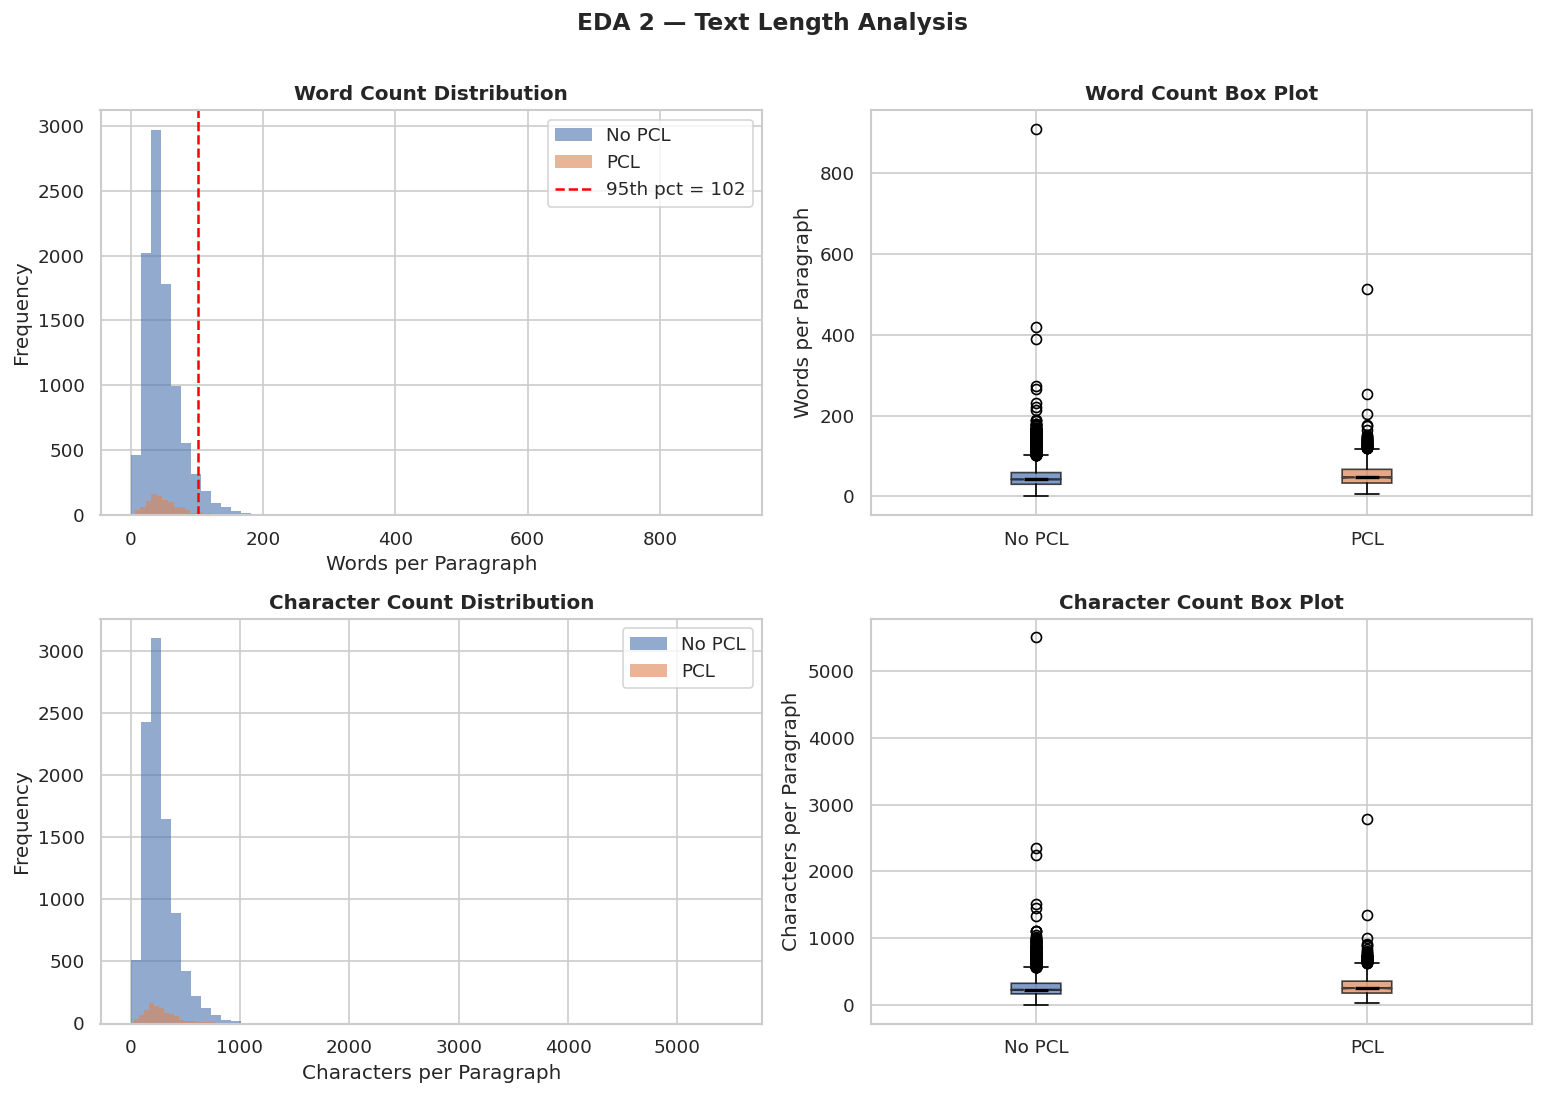

Saved fig2_text_length.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

label_names = {0: 'No PCL', 1: 'PCL'}

# Row 0: Word count
for lbl, color in PCL_COLORS.items():
    subset = df[df['label'] == lbl]['word_count']
    axes[0, 0].hist(subset, bins=60, alpha=0.6, color=color,
                    label=label_names[lbl], edgecolor='none')
axes[0, 0].set_title('Word Count Distribution', fontweight='bold')
axes[0, 0].set_xlabel('Words per Paragraph')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
# 95th percentile line
p95 = np.percentile(df['word_count'], 95)
axes[0, 0].axvline(p95, color='red', linestyle='--', label=f'95th pct = {p95:.0f}')
axes[0, 0].legend()

# Box plot: word count
data_bp = [df[df['label']==0]['word_count'], df[df['label']==1]['word_count']]
bp = axes[0, 1].boxplot(data_bp, patch_artist=True, notch=True,
                         medianprops={'color':'black','linewidth':2})
for patch, color in zip(bp['boxes'], PCL_COLORS.values()):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0, 1].set_xticklabels(['No PCL', 'PCL'])
axes[0, 1].set_title('Word Count Box Plot', fontweight='bold')
axes[0, 1].set_ylabel('Words per Paragraph')

# Row 1: Char count
for lbl, color in PCL_COLORS.items():
    subset = df[df['label'] == lbl]['char_count']
    axes[1, 0].hist(subset, bins=60, alpha=0.6, color=color,
                    label=label_names[lbl], edgecolor='none')
axes[1, 0].set_title('Character Count Distribution', fontweight='bold')
axes[1, 0].set_xlabel('Characters per Paragraph')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# Box plot: char count
data_bp2 = [df[df['label']==0]['char_count'], df[df['label']==1]['char_count']]
bp2 = axes[1, 1].boxplot(data_bp2, patch_artist=True, notch=True,
                           medianprops={'color':'black','linewidth':2})
for patch, color in zip(bp2['boxes'], PCL_COLORS.values()):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 1].set_xticklabels(['No PCL', 'PCL'])
axes[1, 1].set_title('Character Count Box Plot', fontweight='bold')
axes[1, 1].set_ylabel('Characters per Paragraph')

plt.suptitle('EDA 2 — Text Length Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig2_text_length.png'), bbox_inches='tight')
plt.show()
print('Saved fig2_text_length.png')

---
## EDA 3 — Keyword / Vulnerable-Community Distribution

In [7]:
# ── EDA 3: Keyword Distribution ───────────────────────────────────────────────
kw_counts = df.groupby(['keyword', 'label']).size().unstack(fill_value=0)
kw_counts.columns = ['No PCL', 'PCL']
kw_counts['Total'] = kw_counts.sum(axis=1)
kw_counts['PCL Rate (%)'] = (kw_counts['PCL'] / kw_counts['Total'] * 100).round(1)
kw_counts = kw_counts.sort_values('Total', ascending=False)

print('=== Keyword Statistics ===')
print(kw_counts.to_string())
print(f'\nMost-PCL keyword: {kw_counts["PCL Rate (%)"].idxmax()} ({kw_counts["PCL Rate (%)"].max()}%)')
print(f'Least-PCL keyword: {kw_counts["PCL Rate (%)"].idxmin()} ({kw_counts["PCL Rate (%)"].min()}%)')

=== Keyword Statistics ===
               No PCL  PCL  Total  PCL Rate (%)
keyword                                        
migrant          1053   36   1089           3.3
in-need           906  176   1082          16.3
vulnerable       1000   80   1080           7.4
homeless          899  178   1077          16.5
women            1018   52   1070           4.9
refugee           982   86   1068           8.1
immigrant        1031   30   1061           2.8
disabled          947   81   1028           7.9
hopeless          881  124   1005          12.3
poor-families     759  150    909          16.5

Most-PCL keyword: homeless (16.5%)
Least-PCL keyword: immigrant (2.8%)


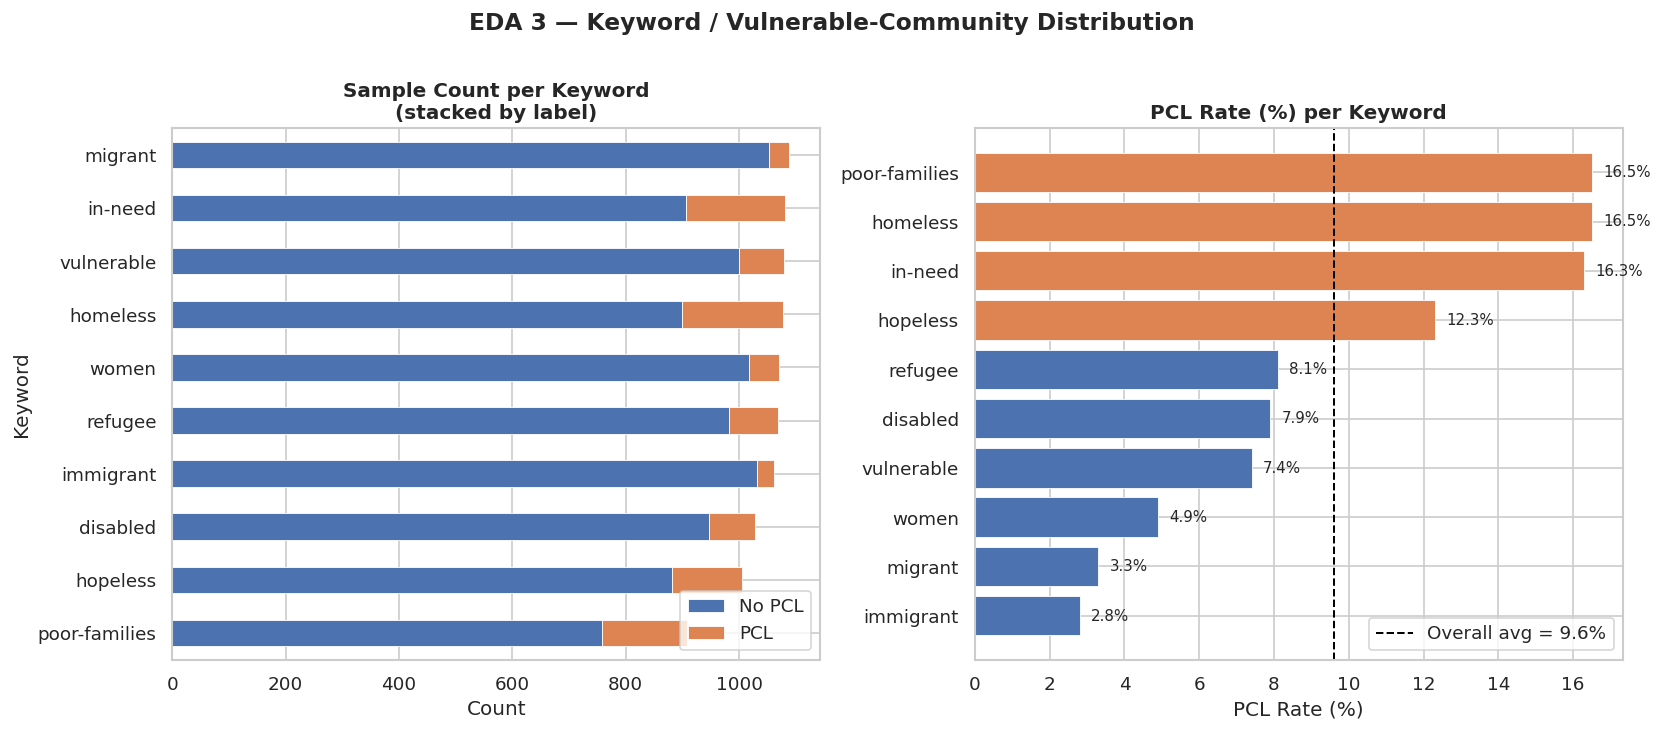

Saved fig3_keyword_distribution.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Stacked bar — counts
kw_plot = kw_counts.sort_values('Total', ascending=True)
kw_plot[['No PCL', 'PCL']].plot(
    kind='barh', stacked=True, ax=axes[0],
    color=[PCL_COLORS[0], PCL_COLORS[1]], edgecolor='white', linewidth=0.5
)
axes[0].set_title('Sample Count per Keyword\n(stacked by label)', fontweight='bold')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Keyword')
axes[0].legend(loc='lower right')

# PCL rate bar
kw_rate = kw_counts.sort_values('PCL Rate (%)', ascending=True)
colors = [PCL_COLORS[1] if r > kw_counts['PCL Rate (%)'].mean() else PCL_COLORS[0]
          for r in kw_rate['PCL Rate (%)']]
axes[1].barh(kw_rate.index, kw_rate['PCL Rate (%)'],
             color=colors, edgecolor='white', linewidth=0.5)
avg_rate = kw_counts['PCL Rate (%)'].mean()
axes[1].axvline(avg_rate, color='black', linestyle='--', linewidth=1.2,
                label=f'Overall avg = {avg_rate:.1f}%')
for i, (_, row) in enumerate(kw_rate.iterrows()):
    axes[1].text(row['PCL Rate (%)'] + 0.3, i, f"{row['PCL Rate (%)']:.1f}%",
                 va='center', fontsize=9)
axes[1].set_title('PCL Rate (%) per Keyword', fontweight='bold')
axes[1].set_xlabel('PCL Rate (%)')
axes[1].legend()

plt.suptitle('EDA 3 — Keyword / Vulnerable-Community Distribution',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig3_keyword_distribution.png'), bbox_inches='tight')
plt.show()
print('Saved fig3_keyword_distribution.png')

---
## EDA 4 — N-gram Analysis (Lexical Patterns)

In [9]:
# ── EDA 4: N-gram Analysis ────────────────────────────────────────────────────
STOP_WORDS = set(stopwords.words('english'))
# Add domain-neutral words that won't be discriminative
STOP_WORDS.update(['said', 'say', 'says', 'also', 'one', 'two', 'three',
                   'would', 'could', 'like', 'us', 'u', 'year', 'years',
                   'new', 'make', 'many', 'get', 'go', 'much', 'even',
                   'around', 'since', 'still', 'however', 'though'])

def tokenize(text):
    tokens = word_tokenize(text.lower())
    return [t for t in tokens if t.isalpha() and t not in STOP_WORDS and len(t) > 1]

def top_ngrams(texts, n, top_k=20):
    all_ng = []
    for text in texts:
        tokens = tokenize(text)
        all_ng.extend(ngrams(tokens, n))
    return Counter(all_ng).most_common(top_k)

pcl_texts    = df[df['label'] == 1]['text'].tolist()
no_pcl_texts = df[df['label'] == 0]['text'].tolist()

print('Computing n-grams (may take ~30 seconds)...')
ng_data = {}
for n, name in [(1, 'Unigrams'), (2, 'Bigrams'), (3, 'Trigrams')]:
    ng_data[name] = {
        'PCL':    top_ngrams(pcl_texts, n),
        'No PCL': top_ngrams(no_pcl_texts, n)
    }
print('Done.')

# Print top-10 for each
for name, data in ng_data.items():
    print(f'\n--- Top-10 {name} ---')
    print(f'{"PCL":40s}  {"No PCL":40s}')
    for (pg, pc), (ng, nc) in zip(data['PCL'][:10], data['No PCL'][:10]):
        print(f'  {", ".join(pg):38s} {pc:5d}   {", ".join(ng):38s} {nc:5d}')

Computing n-grams (may take ~30 seconds)...


Done.

--- Top-10 Unigrams ---
PCL                                       No PCL                                  
  people                                   256   people                                  1584
  need                                     238   women                                   1561
  poor                                     232   immigrants                              1249
  families                                 212   families                                1129
  children                                 199   need                                    1106
  homeless                                 177   vulnerable                              1105
  women                                    144   disabled                                1019
  help                                     136   poor                                     941
  disabled                                 104   refugees                                 870
  vulnerable                            

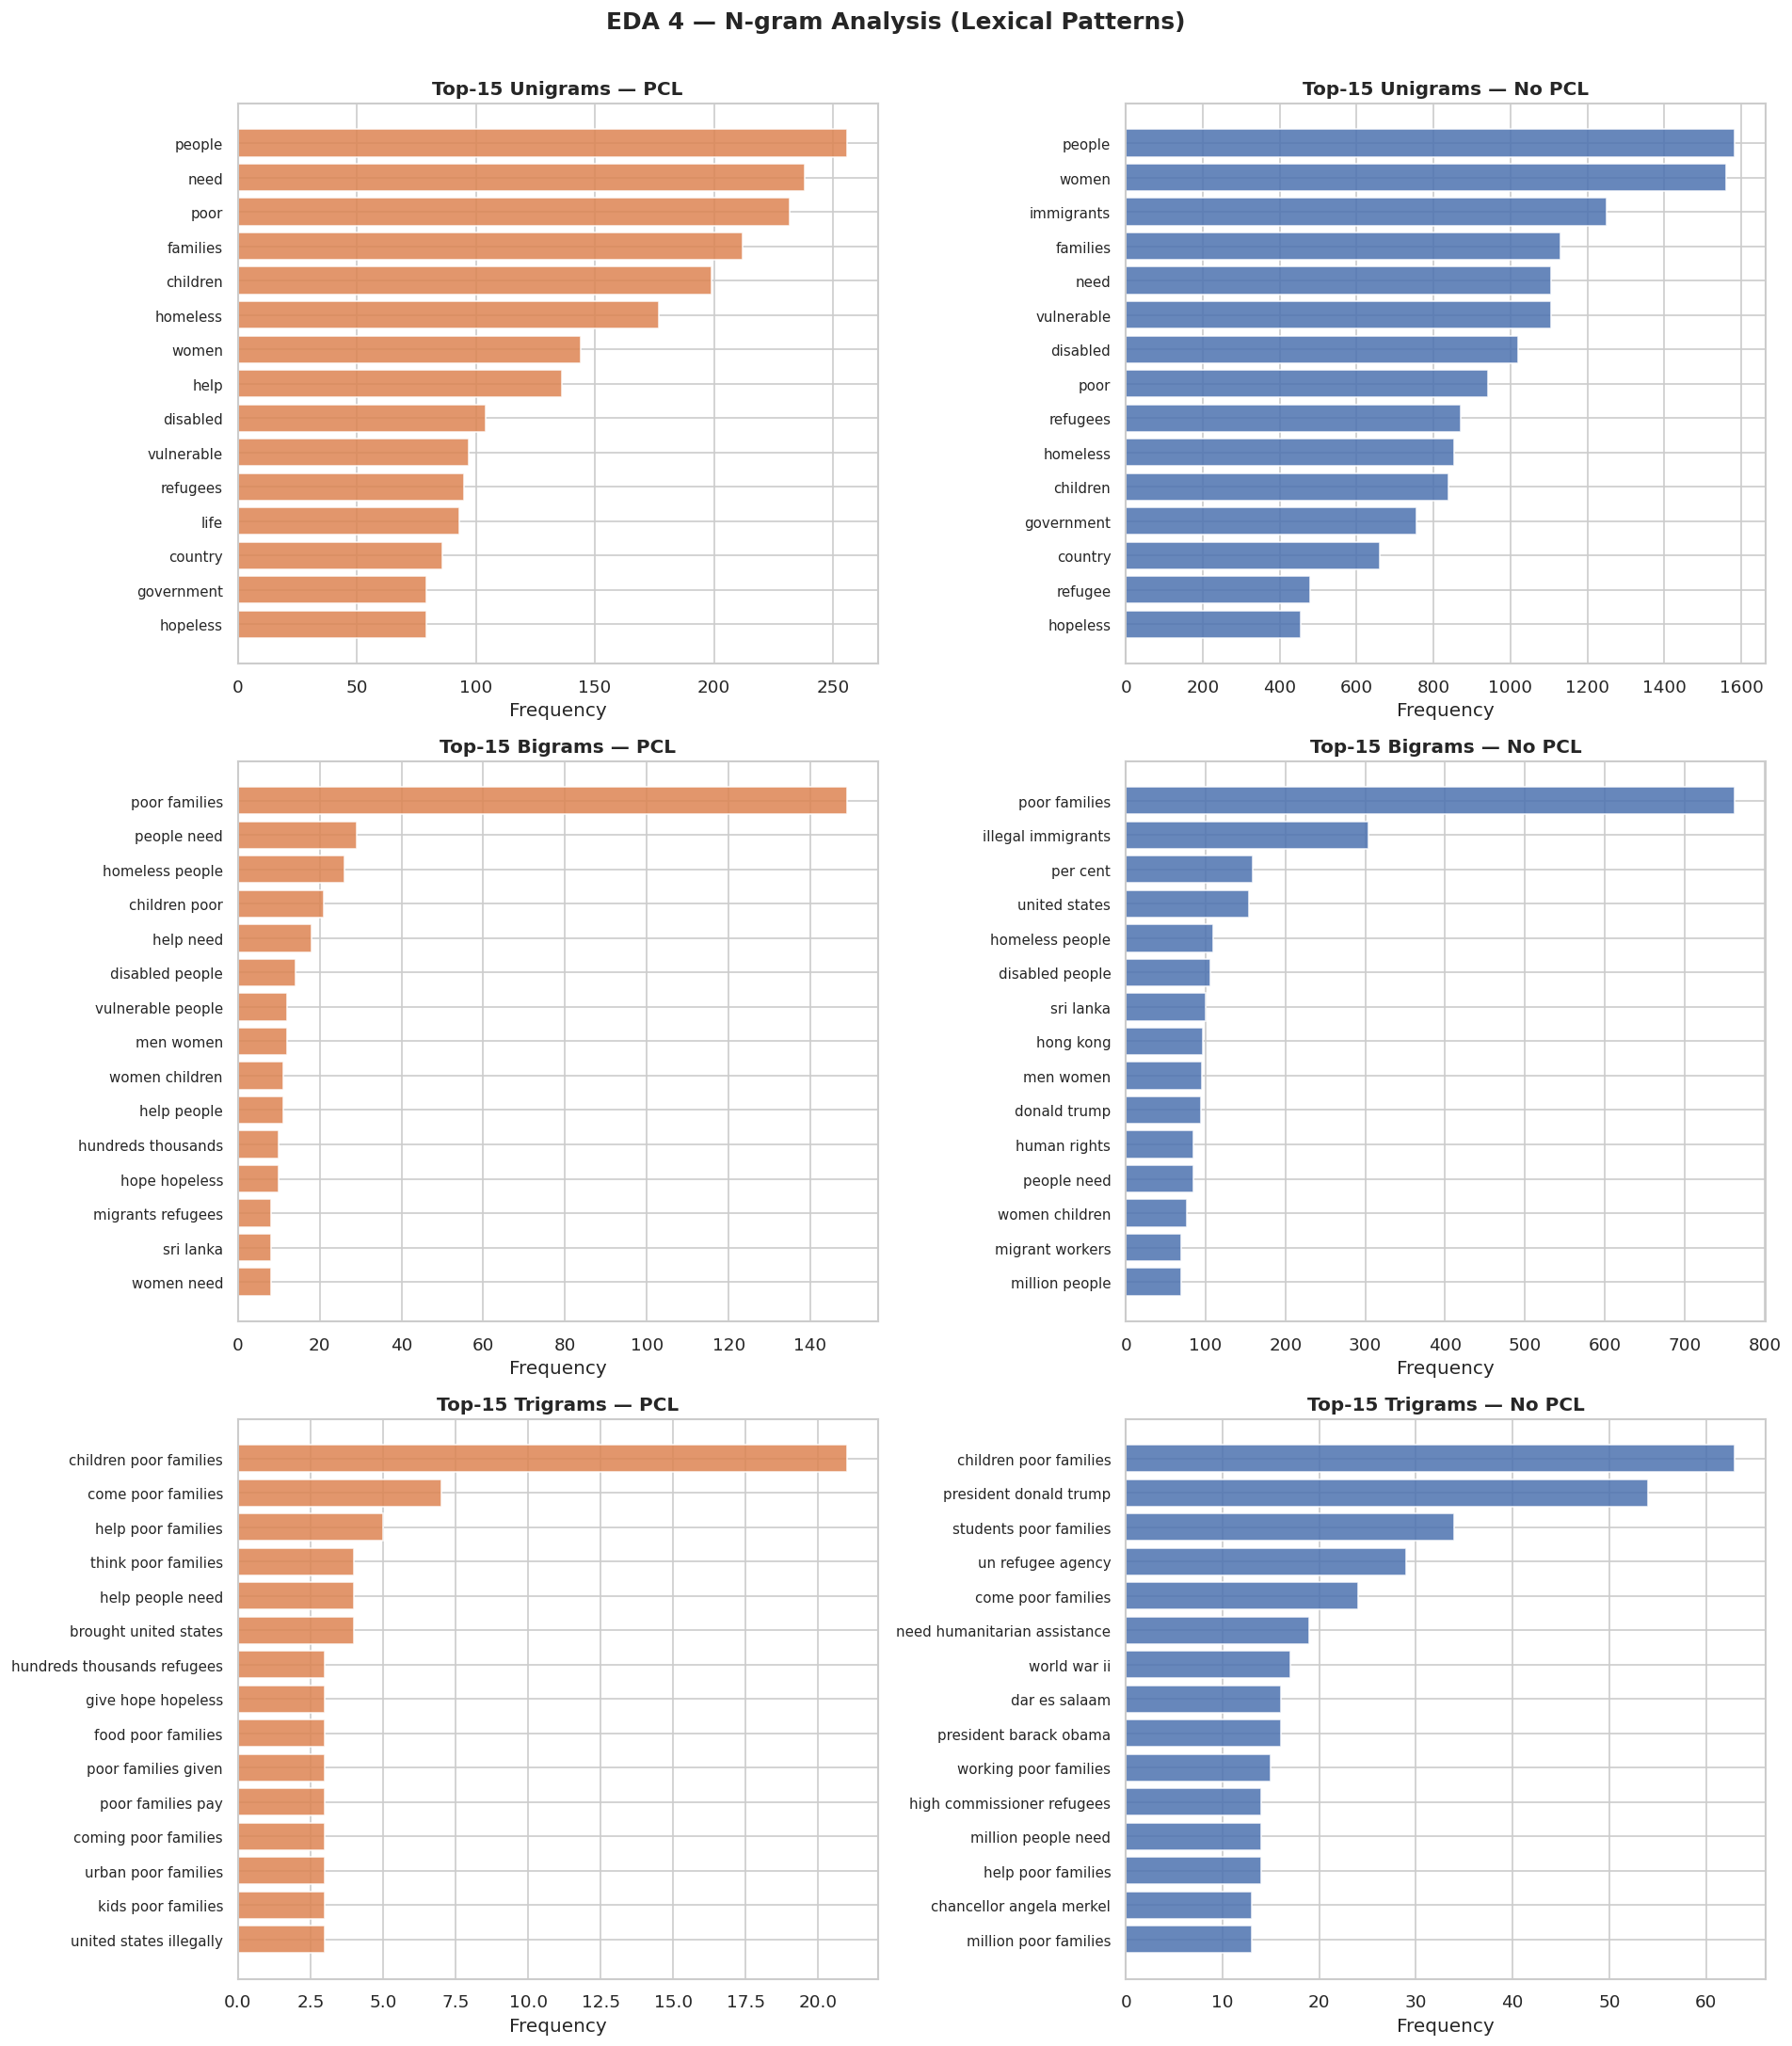

Saved fig4_ngrams.png


In [10]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

for row_idx, (name, data) in enumerate(ng_data.items()):
    for col_idx, (group, color) in enumerate(zip(['PCL', 'No PCL'], [PCL_COLORS[1], PCL_COLORS[0]])):
        top = data[group][:15]
        labels_ng = [' '.join(g) for g, _ in top]
        counts_ng = [c for _, c in top]
        ax = axes[row_idx, col_idx]
        bars = ax.barh(range(len(labels_ng)), counts_ng, color=color, alpha=0.85, edgecolor='white')
        ax.set_yticks(range(len(labels_ng)))
        ax.set_yticklabels(labels_ng, fontsize=9)
        ax.invert_yaxis()
        ax.set_title(f'Top-15 {name} — {group}', fontweight='bold')
        ax.set_xlabel('Frequency')

plt.suptitle('EDA 4 — N-gram Analysis (Lexical Patterns)',
             fontsize=15, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig4_ngrams.png'), bbox_inches='tight')
plt.show()
print('Saved fig4_ngrams.png')

---
## EDA 5 — PCL Category Distribution & Co-occurrence

In [11]:
# ── EDA 5: PCL Category Distribution & Co-occurrence ─────────────────────────
CAT_NAMES = [
    'Unbalanced\npower', 'Shallow\nsolution', 'Presupposition',
    'Authority\nvoice', 'Metaphors', 'Compassion', 'Poorer the\nmerrier'
]
CAT_NAMES_SHORT = [
    'Unbalanced power', 'Shallow solution', 'Presupposition',
    'Authority voice', 'Metaphors', 'Compassion', 'Poorer the merrier'
]

# Extract the 7-element label vectors from task2
label_matrix = np.vstack(df2['label'].values)   # shape: (N_pcl_texts, 7)

# Category frequencies
cat_counts = label_matrix.sum(axis=0)
cat_pct    = cat_counts / label_matrix.shape[0] * 100

print('=== PCL Category Frequencies ===')
cat_df = pd.DataFrame({
    'Category': CAT_NAMES_SHORT,
    'Count': cat_counts.astype(int),
    'Pct of PCL paragraphs (%)': cat_pct.round(1)
})
print(cat_df.sort_values('Count', ascending=False).to_string(index=False))

# Co-occurrence (Pearson correlation between category vectors)
cat_corr = np.corrcoef(label_matrix.T)
print(f'\nTotal PCL-annotated paragraphs: {label_matrix.shape[0]}')
print(f'Average categories per paragraph: {label_matrix.sum(axis=1).mean():.2f}')

=== PCL Category Frequencies ===
          Category  Count  Pct of PCL paragraphs (%)
  Unbalanced power    716                       72.1
        Compassion    469                       47.2
   Authority voice    230                       23.2
    Presupposition    224                       22.6
         Metaphors    197                       19.8
  Shallow solution    196                       19.7
Poorer the merrier     40                        4.0

Total PCL-annotated paragraphs: 993
Average categories per paragraph: 2.09


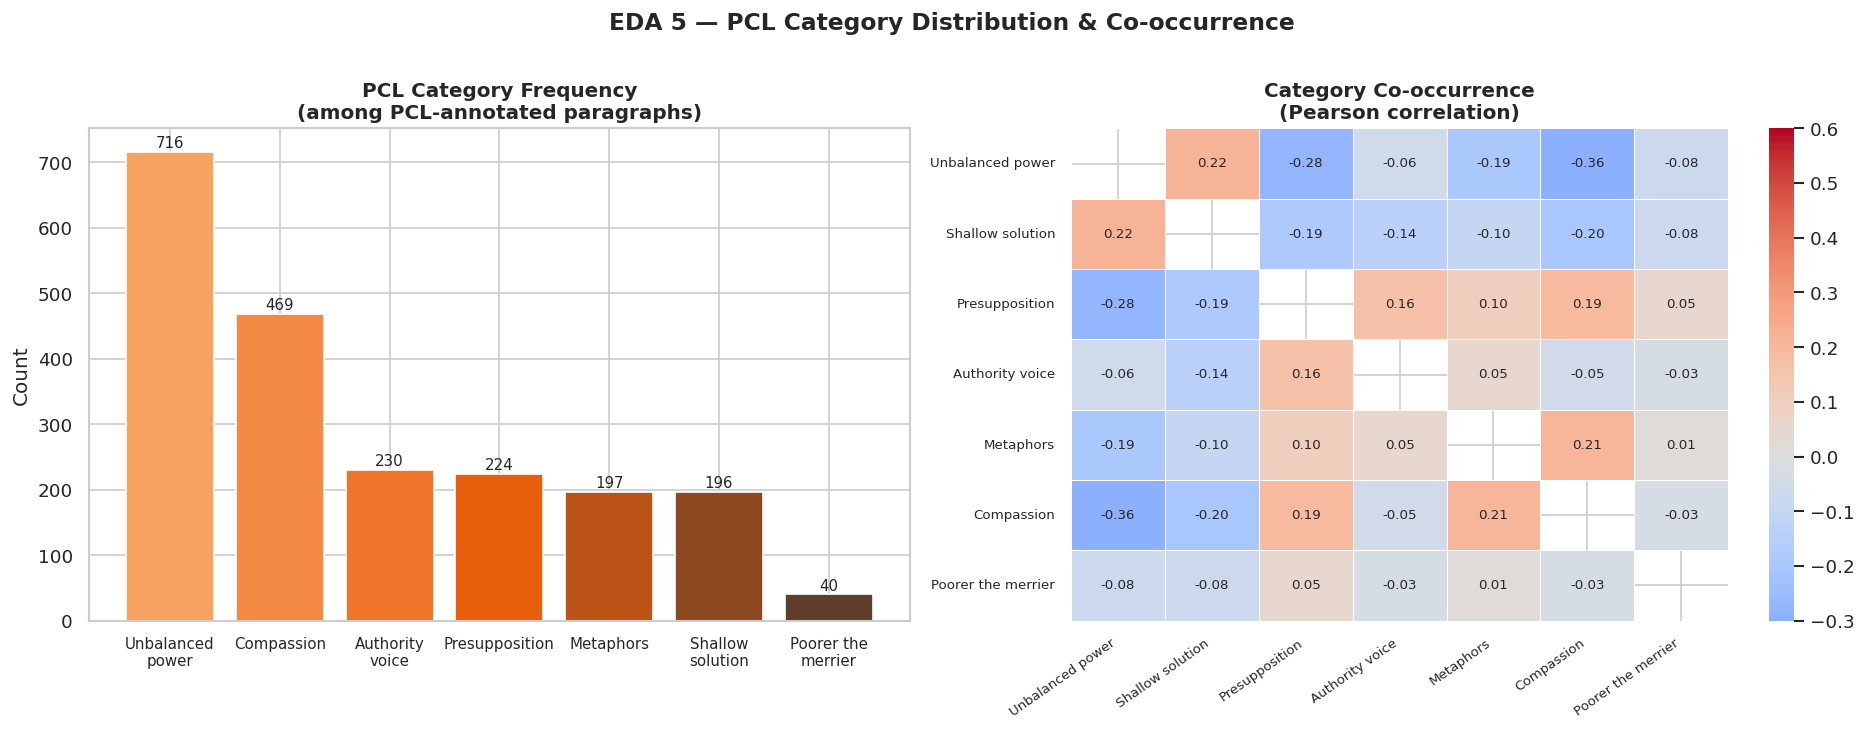

Saved fig5_pcl_categories.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of category frequencies
order = np.argsort(cat_counts)[::-1]
palette = sns.color_palette('Oranges_d', 7)
axes[0].bar(
    np.arange(7), cat_counts[order],
    color=[palette[i] for i in range(7)],
    edgecolor='white'
)
axes[0].set_xticks(np.arange(7))
axes[0].set_xticklabels([CAT_NAMES[i] for i in order], fontsize=9)
for i, c in enumerate(cat_counts[order]):
    axes[0].text(i, c + 2, str(c), ha='center', va='bottom', fontsize=9)
axes[0].set_title('PCL Category Frequency\n(among PCL-annotated paragraphs)', fontweight='bold')
axes[0].set_ylabel('Count')

# Heatmap: co-occurrence correlation
mask = np.eye(7, dtype=bool)
sns.heatmap(
    cat_corr, annot=True, fmt='.2f', mask=mask,
    cmap='coolwarm', center=0, vmin=-0.3, vmax=0.6,
    xticklabels=CAT_NAMES_SHORT, yticklabels=CAT_NAMES_SHORT,
    ax=axes[1], linewidths=0.5, linecolor='white',
    annot_kws={'size': 8}
)
axes[1].set_title('Category Co-occurrence\n(Pearson correlation)', fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=35, ha='right', fontsize=8)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0, fontsize=8)

plt.suptitle('EDA 5 — PCL Category Distribution & Co-occurrence',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig5_pcl_categories.png'), bbox_inches='tight')
plt.show()
print('Saved fig5_pcl_categories.png')

---
## EDA 6 — Word Cloud Visualisation

Computing TF-IDF weights...


Done.


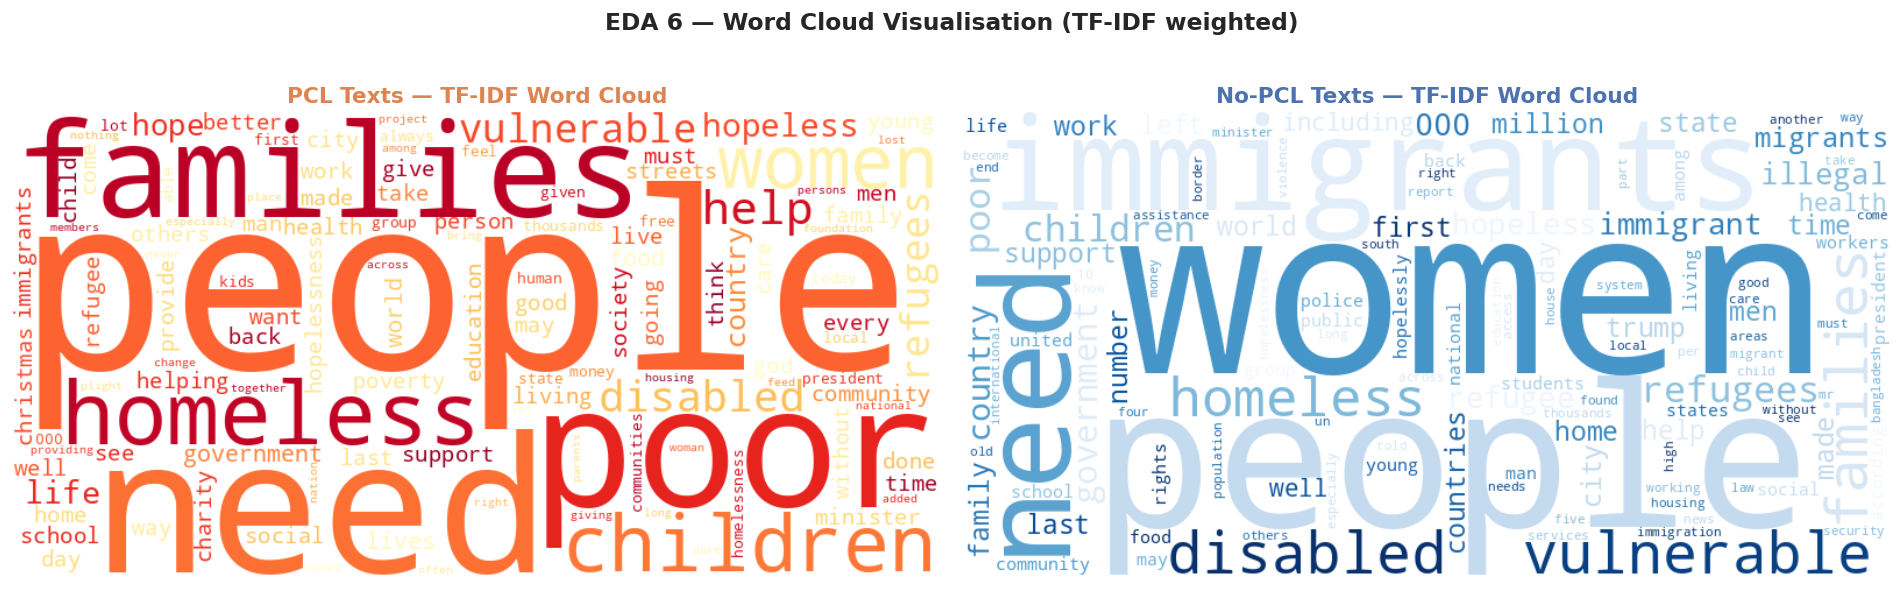

Saved fig6_wordclouds.png


In [13]:
# ── EDA 6: Word Clouds ────────────────────────────────────────────────────────
# Use TF-IDF scores as word weights so the clouds highlight *distinctive* words
# rather than simply the most frequent ones.
from sklearn.feature_extraction.text import TfidfVectorizer

def make_tfidf_weights(texts, stop_words):
    vec = TfidfVectorizer(stop_words=list(stop_words), max_features=3000,
                           ngram_range=(1, 1), min_df=2)
    X = vec.fit_transform(texts)
    scores = np.asarray(X.mean(axis=0)).flatten()
    return dict(zip(vec.get_feature_names_out(), scores))

print('Computing TF-IDF weights...')
pcl_weights    = make_tfidf_weights(pcl_texts,    STOP_WORDS)
no_pcl_weights = make_tfidf_weights(no_pcl_texts, STOP_WORDS)
print('Done.')

wc_pcl = WordCloud(
    width=800, height=400, background_color='white',
    colormap='YlOrRd', max_words=120, prefer_horizontal=0.9
).generate_from_frequencies(pcl_weights)

wc_no_pcl = WordCloud(
    width=800, height=400, background_color='white',
    colormap='Blues', max_words=120, prefer_horizontal=0.9
).generate_from_frequencies(no_pcl_weights)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].imshow(wc_pcl, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('PCL Texts — TF-IDF Word Cloud', fontweight='bold', fontsize=13, color=PCL_COLORS[1])

axes[1].imshow(wc_no_pcl, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('No-PCL Texts — TF-IDF Word Cloud', fontweight='bold', fontsize=13, color=PCL_COLORS[0])

plt.suptitle('EDA 6 — Word Cloud Visualisation (TF-IDF weighted)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig6_wordclouds.png'), bbox_inches='tight')
plt.show()
print('Saved fig6_wordclouds.png')

In [14]:
# ── Final summary ─────────────────────────────────────────────────────────────
print('=== All EDA figures saved ===')
for f in sorted(os.listdir(FIG_DIR)):
    fpath = os.path.join(FIG_DIR, f)
    print(f'  {f:40s}  ({os.path.getsize(fpath)//1024} KB)')

=== All EDA figures saved ===
  fig1_class_distribution.png               (54 KB)
  fig2_text_length.png                      (111 KB)
  fig3_keyword_distribution.png             (97 KB)
  fig4_ngrams.png                           (247 KB)
  fig5_pcl_categories.png                   (132 KB)
  fig6_wordclouds.png                       (549 KB)
